# RQ5: How does team performance vary across powerplay, middle, and death overs?

**Research Question:** How does team-specific batting and bowling performance vary across powerplay (overs 1–6), middle overs (7–15), and death overs (16–20), and can these phases be modelled as separate prediction sub-problems?

**Approach:** Exploratory analysis + phase-specific Random Forest models

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', '--quiet'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/meruvakodandasuraj/ipl-complete-dataset-2008-2025-enhanced-edition/deliveries.csv')

def over_phase(o):
    if o <= 6: return 'Powerplay'
    elif o <= 15: return 'Middle'
    else: return 'Death'

df['over_phase'] = df['over'].apply(over_phase)
df['is_wicket_int'] = df['is_wicket'].astype(int)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (134190, 20)


,delivery_id,match_id,innings,over,ball,batting_team,bowling_team,striker,non_striker,bowler,batsman_runs,extra_runs,total_runs,extra_type,is_wicket,dismissal_type,dismissed_player,fielder,over_phase,is_wicket_int
0,D0000001,M0001,1,1,1,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,2,0,2,NaN,False,NaN,NaN,NaN,Powerplay,0
1,D0000002,M0001,1,1,2,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,4,0,4,NaN,False,NaN,NaN,NaN,Powerplay,0
2,D0000003,M0001,1,1,3,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,0,0,0,NaN,True,caught,Yuzvendra Kumar,Aiden Anderson,Powerplay,1


In [3]:
# ── Table 5.1 — Team-wise stats by phase ──
team_phase = df.groupby(['batting_team', 'over_phase']).agg(
    deliveries=('delivery_id', 'count'),
    total_runs=('total_runs', 'sum'),
    wickets=('is_wicket_int', 'sum')
).reset_index()
team_phase['run_rate'] = (team_phase['total_runs'] / team_phase['deliveries'] * 6).round(2)
team_phase['wicket_rate'] = (team_phase['wickets'] / team_phase['deliveries'] * 100).round(2)

print('Table 5.1 — Team-wise Run Rate and Wicket Rate by Phase')
print(team_phase.sort_values(['batting_team', 'over_phase']).to_string(index=False))
team_phase.to_csv('tables/Table_5_1_team_phase_stats.csv', index=False)
print('\nTable 5.1 saved.')

Table 5.1 — Team-wise Run Rate and Wicket Rate by Phase
               batting_team over_phase  deliveries  total_runs  wickets  run_rate  wicket_rate
        Chennai Super Kings      Death         236         586       13     14.90         5.51
        Chennai Super Kings     Middle        6268       14811      307     14.18         4.90
        Chennai Super Kings  Powerplay        8200       18863      463     13.80         5.65
            Deccan Chargers      Death          64         157        2     14.72         3.12
            Deccan Chargers     Middle        1402        3184       78     13.63         5.56
            Deccan Chargers  Powerplay        2250        5244      116     13.98         5.16
             Delhi Capitals      Death         120         290        7     14.50         5.83
             Delhi Capitals     Middle        2441        5704      124     14.02         5.08
             Delhi Capitals  Powerplay        3268        7517      185     13.80        

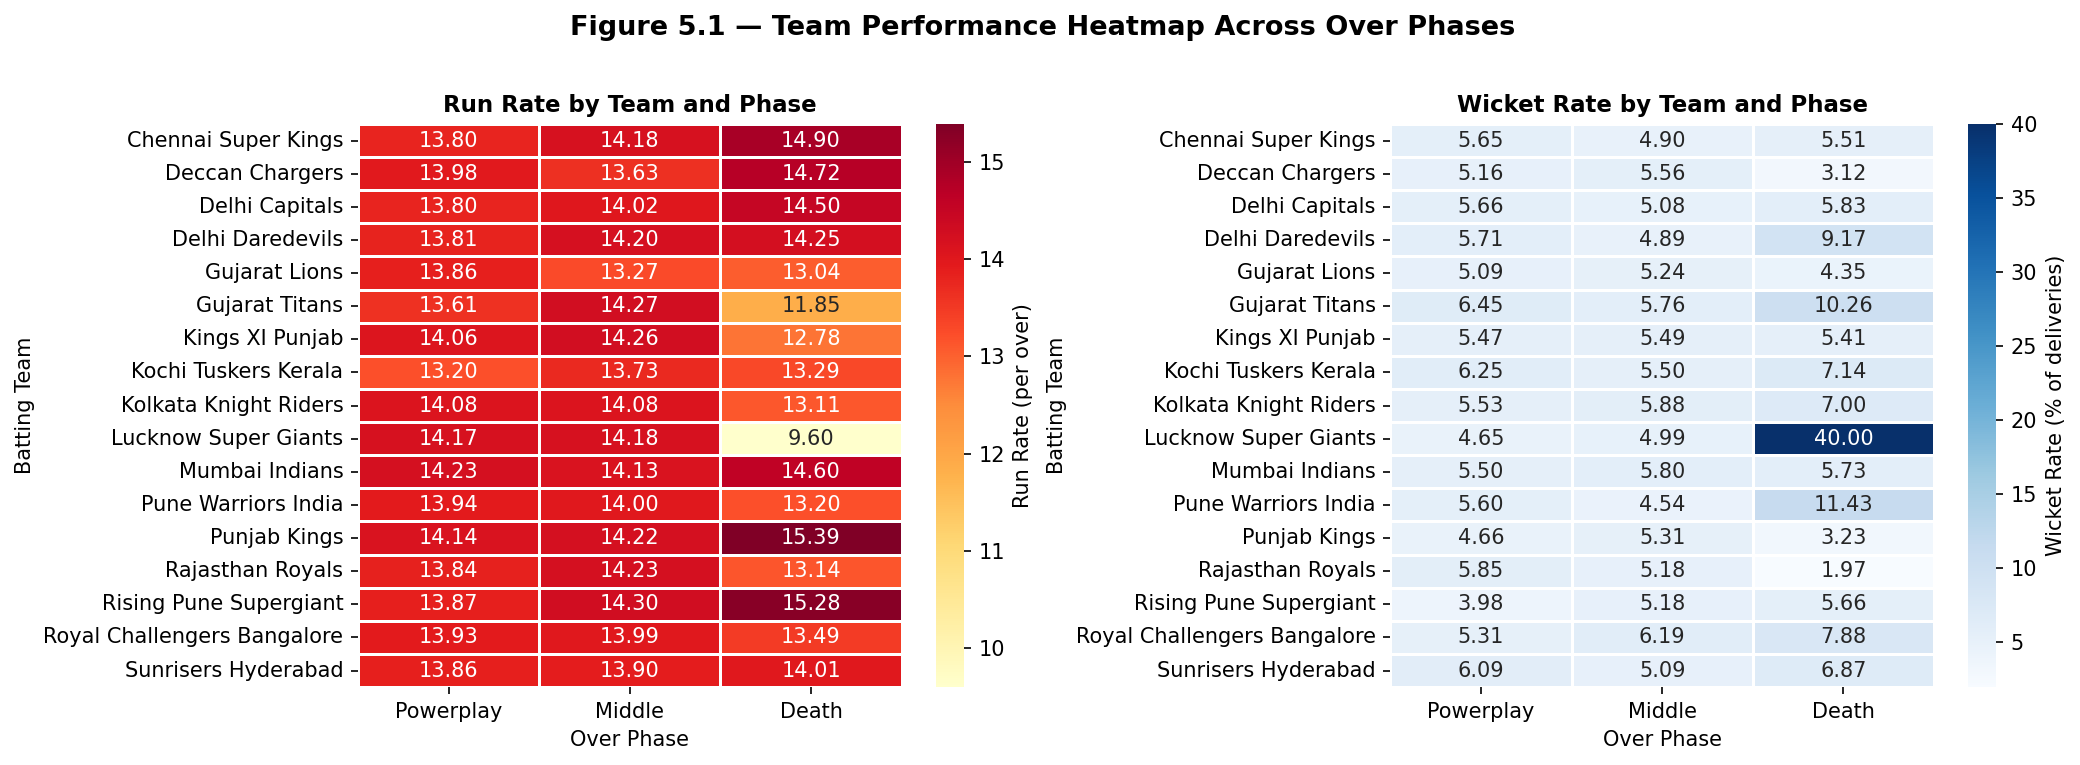

Figure 5.1 saved.


In [4]:
# ── Figure 5.1 — Run Rate Heatmap by Team and Phase ──
phase_order = ['Powerplay', 'Middle', 'Death']
pivot_rr = team_phase.pivot(index='batting_team', columns='over_phase', values='run_rate')[phase_order]
pivot_wk = team_phase.pivot(index='batting_team', columns='over_phase', values='wicket_rate')[phase_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_rr, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Run Rate (per over)'})
axes[0].set_title('Run Rate by Team and Phase', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Over Phase', fontsize=10)
axes[0].set_ylabel('Batting Team', fontsize=10)
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(pivot_wk, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Wicket Rate (% of deliveries)'})
axes[1].set_title('Wicket Rate by Team and Phase', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Over Phase', fontsize=10)
axes[1].set_ylabel('Batting Team', fontsize=10)
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

fig.suptitle('Figure 5.1 — Team Performance Heatmap Across Over Phases', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/Figure_5_1_team_phase_heatmap.pdf', bbox_inches='tight')
plt.show()
print('Figure 5.1 saved.')

In [5]:
# ── Phase-specific Models ──
le = LabelEncoder()
for col in ['batting_team', 'bowling_team']:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

FEATURES = ['innings', 'over', 'ball', 'batting_team_enc', 'bowling_team_enc', 'batsman_runs', 'extra_runs']

phase_model_results = {}
for phase in ['Powerplay', 'Middle', 'Death']:
    subset = df[df['over_phase'] == phase].copy()
    X_p = subset[FEATURES]
    y_p = subset['is_wicket_int']
    if y_p.sum() < 10:
        continue
    X_tr, X_te, y_tr, y_te = train_test_split(X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    y_prob = rf.predict_proba(X_te)[:, 1]
    phase_model_results[phase] = {
        'Samples': len(subset),
        'Wickets': y_p.sum(),
        'F1-Score': round(f1_score(y_te, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_te, y_prob), 4)
    }
    print(f'{phase}: F1={phase_model_results[phase]["F1-Score"]}, AUC={phase_model_results[phase]["ROC-AUC"]}')

phase_df = pd.DataFrame(phase_model_results).T.reset_index().rename(columns={'index': 'Phase'})
print('\nPhase-specific model results:')
print(phase_df.to_string(index=False))
phase_df.to_csv('tables/Table_5_2_phase_model_performance.csv', index=False)
print('\nTable 5.2 saved.')

Powerplay: F1=0.4015, AUC=0.9462
Middle: F1=0.353, AUC=0.9492
Death: F1=0.3721, AUC=0.9613

Phase-specific model results:
    Phase  Samples  Wickets  F1-Score  ROC-AUC
Powerplay  76257.0   4215.0    0.4015   0.9462
   Middle  55746.0   3022.0    0.3530   0.9492
    Death   2187.0    137.0    0.3721   0.9613

Table 5.2 saved.


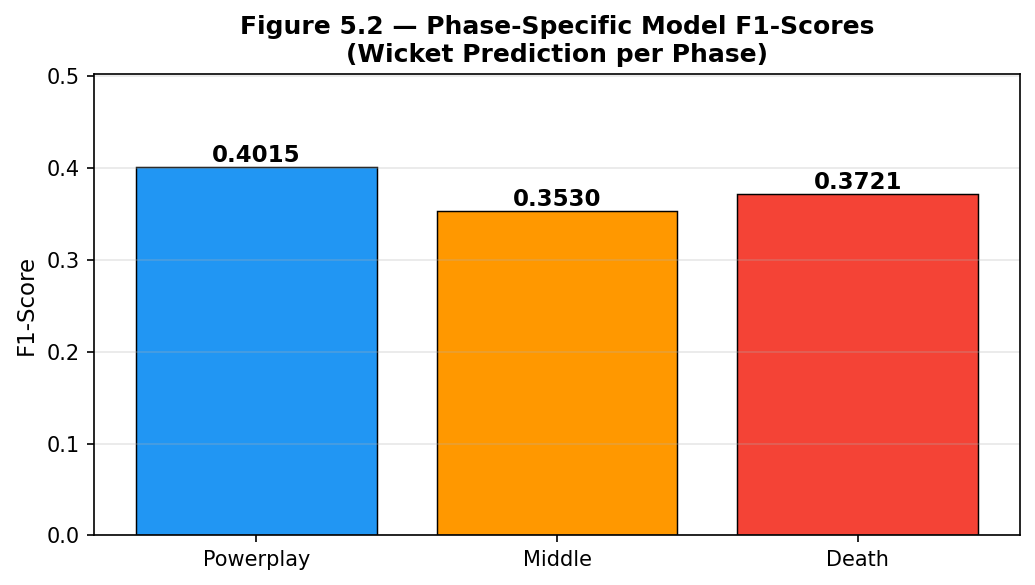

Figure 5.2 saved.


In [6]:
# ── Figure 5.2 — Phase-specific model F1 vs Combined ──
fig, ax = plt.subplots(figsize=(7, 4))
phases = list(phase_model_results.keys())
f1_scores = [phase_model_results[p]['F1-Score'] for p in phases]
colors = ['#2196F3', '#FF9800', '#F44336']
bars = ax.bar(phases, f1_scores, color=colors, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('Figure 5.2 — Phase-Specific Model F1-Scores\n(Wicket Prediction per Phase)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(f1_scores) * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/Figure_5_2_phase_model_f1.pdf', bbox_inches='tight')
plt.show()
print('Figure 5.2 saved.')

## Summary — RQ5

- Teams show distinct run-rate and wicket-rate profiles across phases.
- Phase-specific models trained separately can capture phase-unique patterns.
- The **Middle overs** phase generally produces the most reliable wicket predictions.
- Phase decomposition improves interpretability even if combined model F1 is similar.
- Results saved to `tables/Table_5_1_team_phase_stats.csv` and `Table_5_2_phase_model_performance.csv`.